### **Walmart Sales and Operational Performance Analysis**
#### **Background and Objective**
This project analyzes operational transaction data across various Walmart branches. The **primary objective** is to **identify revenue trends**, **evaluate product category performance**, and **map customer shopping patterns**. The insights extracted from this analysis are designed to provide management with actionable recommendations for labor optimization, targeted sales strategies, and payment method promotions.

#### **Methodology**
Data extraction was conducted using **PostgreSQL** queries to address specific operational business questions. The extracted data was then processed using Pandas and visualized with Matplotlib and Seaborn in **Python** to highlight key trends impacting business decisions.

**Data Exploration & Leading**

In [ ]:
#importing dependencies
import pandas as pd
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns

#data frame
df = pd.read_csv('data/Walmart.csv', encoding_errors='ignore')

## SQL toolkit - load credentials from .env file (not hardcoded)
load_dotenv()
db_user = os.getenv("DB_USER")
db_password = os.getenv("DB_PASSWORD")
db_host = os.getenv("DB_HOST")
db_port = os.getenv("DB_PORT")
db_name = os.getenv("DB_NAME")

engine = create_engine(f'postgresql://{db_user}:{db_password}@{db_host}:{db_port}/{db_name}')

In [36]:
df.head()

,invoice_id,Branch,City,category,unit_price,quantity,date,time,payment_method,rating,profit_margin
0,1,WALM003,San Antonio,Health and beauty,$74.69,7.0,05/01/19,13:08:00,Ewallet,9.1,0.48
1,2,WALM048,Harlingen,Electronic accessories,$15.28,5.0,08/03/19,10:29:00,Cash,9.6,0.48
2,3,WALM067,Haltom City,Home and lifestyle,$46.33,7.0,03/03/19,13:23:00,Credit card,7.4,0.33
3,4,WALM064,Bedford,Health and beauty,$58.22,8.0,27/01/19,20:33:00,Ewallet,8.4,0.33
4,5,WALM013,Irving,Sports and travel,$86.31,7.0,08/02/19,10:37:00,Ewallet,5.3,0.48


In [37]:
df.describe()

,invoice_id,quantity,rating,profit_margin
count,10051.000000,10020.000000,10051.000000,10051.000000
mean,5025.741220,2.353493,5.825659,0.393791
std,2901.174372,1.602658,1.763991,0.090669
min,1.000000,1.000000,3.000000,0.180000
25%,2513.500000,1.000000,4.000000,0.330000
50%,5026.000000,2.000000,6.000000,0.330000
75%,7538.500000,3.000000,7.000000,0.480000
max,10000.000000,10.000000,10.000000,0.570000


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10051 entries, 0 to 10050
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_id      10051 non-null  int64  
 1   Branch          10051 non-null  object 
 2   City            10051 non-null  object 
 3   category        10051 non-null  object 
 4   unit_price      10020 non-null  object 
 5   quantity        10020 non-null  float64
 6   date            10051 non-null  object 
 7   time            10051 non-null  object 
 8   payment_method  10051 non-null  object 
 9   rating          10051 non-null  float64
 10  profit_margin   10051 non-null  float64
dtypes: float64(3), int64(1), object(7)
memory usage: 863.9+ KB


In [39]:
#all duplicated
df.duplicated().sum()

51

In [40]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

0

In [41]:
df.isnull().sum()  

invoice_id         0
Branch             0
City               0
category           0
unit_price        31
quantity          31
date               0
time               0
payment_method     0
rating             0
profit_margin      0
dtype: int64

In [42]:
#dropping all rows with missing values
df.dropna(inplace=True)
#verifying if all missing values are dropped
df.isnull().sum()

invoice_id        0
Branch            0
City              0
category          0
unit_price        0
quantity          0
date              0
time              0
payment_method    0
rating            0
profit_margin     0
dtype: int64

In [43]:
df.dtypes

invoice_id          int64
Branch             object
City               object
category           object
unit_price         object
quantity          float64
date               object
time               object
payment_method     object
rating            float64
profit_margin     float64
dtype: object

In [44]:
df['date'] = pd.to_datetime(df['date'], format='%d/%m/%y')
df['time'] = pd.to_datetime(df['time'], format='%H:%M:%S', errors='coerce').dt.time
df.head()

,invoice_id,Branch,City,category,unit_price,quantity,date,time,payment_method,rating,profit_margin
0,1,WALM003,San Antonio,Health and beauty,$74.69,7.0,2019-01-05,13:08:00,Ewallet,9.1,0.48
1,2,WALM048,Harlingen,Electronic accessories,$15.28,5.0,2019-03-08,10:29:00,Cash,9.6,0.48
2,3,WALM067,Haltom City,Home and lifestyle,$46.33,7.0,2019-03-03,13:23:00,Credit card,7.4,0.33
3,4,WALM064,Bedford,Health and beauty,$58.22,8.0,2019-01-27,20:33:00,Ewallet,8.4,0.33
4,5,WALM013,Irving,Sports and travel,$86.31,7.0,2019-02-08,10:37:00,Ewallet,5.3,0.48


In [45]:
df['unit_price'] = pd.to_numeric(
    df['unit_price'].astype(str).str.replace('$', '', regex=False),
    errors='coerce'
).astype('float')
df.head()

,invoice_id,Branch,City,category,unit_price,quantity,date,time,payment_method,rating,profit_margin
0,1,WALM003,San Antonio,Health and beauty,74.69,7.0,2019-01-05,13:08:00,Ewallet,9.1,0.48
1,2,WALM048,Harlingen,Electronic accessories,15.28,5.0,2019-03-08,10:29:00,Cash,9.6,0.48
2,3,WALM067,Haltom City,Home and lifestyle,46.33,7.0,2019-03-03,13:23:00,Credit card,7.4,0.33
3,4,WALM064,Bedford,Health and beauty,58.22,8.0,2019-01-27,20:33:00,Ewallet,8.4,0.33
4,5,WALM013,Irving,Sports and travel,86.31,7.0,2019-02-08,10:37:00,Ewallet,5.3,0.48


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9969 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   invoice_id      9969 non-null   int64         
 1   Branch          9969 non-null   object        
 2   City            9969 non-null   object        
 3   category        9969 non-null   object        
 4   unit_price      9969 non-null   float64       
 5   quantity        9969 non-null   float64       
 6   date            9969 non-null   datetime64[ns]
 7   time            9969 non-null   object        
 8   payment_method  9969 non-null   object        
 9   rating          9969 non-null   float64       
 10  profit_margin   9969 non-null   float64       
dtypes: datetime64[ns](1), float64(4), int64(1), object(5)
memory usage: 934.6+ KB


In [47]:
df.columns

Index(['invoice_id', 'Branch', 'City', 'category', 'unit_price', 'quantity',
       'date', 'time', 'payment_method', 'rating', 'profit_margin'],
      dtype='object')

In [48]:
df['Total']=df['unit_price']*df['quantity']
df.head()

,invoice_id,Branch,City,category,unit_price,quantity,date,time,payment_method,rating,profit_margin,Total
0,1,WALM003,San Antonio,Health and beauty,74.69,7.0,2019-01-05,13:08:00,Ewallet,9.1,0.48,522.83
1,2,WALM048,Harlingen,Electronic accessories,15.28,5.0,2019-03-08,10:29:00,Cash,9.6,0.48,76.40
2,3,WALM067,Haltom City,Home and lifestyle,46.33,7.0,2019-03-03,13:23:00,Credit card,7.4,0.33,324.31
3,4,WALM064,Bedford,Health and beauty,58.22,8.0,2019-01-27,20:33:00,Ewallet,8.4,0.33,465.76
4,5,WALM013,Irving,Sports and travel,86.31,7.0,2019-02-08,10:37:00,Ewallet,5.3,0.48,604.17


**WALMART BUSINESS ANALYSIS**

In [49]:
df.to_sql(name='walmart_sales', con=engine, if_exists='replace', index=False)

969

In [50]:
df.to_csv('walmart_clean_data.csv', index=False)

**Analyze Payment Methods and Sales**

In [51]:
payment_query = """
SELECT
    payment_method,
    COUNT(invoice_id) AS total_transactions,
    SUM(quantity) AS total_items_sold
FROM walmart_sales
GROUP BY payment_method
ORDER BY total_transactions DESC;
"""
payment_results = pd.read_sql(payment_query, engine)
display(payment_results)


,payment_method,total_transactions,total_items_sold
0,Credit card,4256,9567.0
1,Ewallet,3881,8932.0
2,Cash,1832,4984.0


**Identify the Highest-Rated Category in Each Branch**

In [52]:
rating_query = """
WITH CategoryRatings AS (
    SELECT
        "Branch",
        "category",
        AVG(rating) AS average_rating,
        RANK() OVER(PARTITION BY "Branch" ORDER BY AVG(rating) DESC) AS rank
    FROM walmart_sales
    GROUP BY "Branch", "category"
    )
SELECT
    "Branch",
    category,
    average_rating
FROM CategoryRatings
WHERE rank = 1
"""
hasil_rating = pd.read_sql(rating_query, engine)
display(hasil_rating)

,Branch,category,average_rating
0,WALM001,Electronic accessories,7.450000
1,WALM002,Food and beverages,8.250000
2,WALM003,Sports and travel,7.500000
3,WALM004,Food and beverages,9.300000
4,WALM005,Health and beauty,8.366667
...,...,...,...
96,WALM096,Sports and travel,9.600000
97,WALM097,Food and beverages,7.675000
98,WALM098,Health and beauty,9.800000
99,WALM099,Electronic accessories,5.950000


**Determine the Busiest Day for Each Branch**


In [53]:
busiest_day_query = """
WITH TransactionDay AS (
    SELECT
        "Branch",
        TRIM(TO_CHAR("date", 'Day')) AS name_of_day,
        COUNT(invoice_id) AS total_transactions,
        RANK() OVER(PARTITION BY "Branch" ORDER BY Count(invoice_id) DESC) AS rank
    FROM walmart_sales
    GROUP BY "Branch", TO_CHAR("date",'Day')
)
SELECT
    "Branch",
    name_of_day,
    total_transactions
FROM TransactionDay
WHERE rank = 1
"""
busiest_day = pd.read_sql(busiest_day_query, engine)
display(busiest_day)

,Branch,name_of_day,total_transactions
0,WALM001,Thursday,16
1,WALM002,Thursday,15
2,WALM003,Tuesday,33
3,WALM004,Sunday,14
4,WALM005,Wednesday,19
...,...,...,...
109,WALM096,Tuesday,15
110,WALM097,Friday,12
111,WALM098,Monday,18
112,WALM099,Sunday,30


**Calculate Total Quantity Sold by Payment Method**

In [54]:
quantity_query = """
SELECT
    payment_method,
    SUM(quantity) AS total_items_sold
FROM walmart_sales
GROUP BY payment_method
ORDER BY total_items_sold DESC;
"""

quantity_results = pd.read_sql(quantity_query, engine)
display(quantity_results)

,payment_method,total_items_sold
0,Credit card,9567.0
1,Ewallet,8932.0
2,Cash,4984.0


**Analyze Category Ratings by City**

In [55]:
rating_by_city_query = """
SELECT
    "City",
    category,
    AVG(rating) AS average_rating,
    MIN(rating) AS min_rating,
    MAX(rating) AS max_rating
FROM walmart_sales
GROUP BY "City", category
ORDER BY "City", category;
"""
rating_by_city_results = pd.read_sql(rating_by_city_query, engine)
display(rating_by_city_results)

,City,category,average_rating,min_rating,max_rating
0,Abilene,Electronic accessories,7.966667,7.1,8.8
1,Abilene,Fashion accessories,6.240625,4.0,9.0
2,Abilene,Food and beverages,6.950000,6.0,8.9
3,Abilene,Health and beauty,9.700000,9.7,9.7
4,Abilene,Home and lifestyle,6.096875,4.0,9.0
...,...,...,...,...,...
508,Weslaco,Fashion accessories,5.042012,3.0,9.5
509,Weslaco,Food and beverages,8.733333,7.1,9.8
510,Weslaco,Health and beauty,6.750000,4.3,9.2
511,Weslaco,Home and lifestyle,5.183505,3.0,9.2


**Calculate Total Profit by Category**

In [56]:
total_profit_query = """
SELECT 
    category,
    ROUND(SUM("Total")::numeric, 2) AS total_revenue,
    ROUND(SUM("Total" * "profit_margin")::numeric, 2) AS total_profit
FROM walmart_sales
GROUP BY category
ORDER BY total_profit DESC;
"""
total_profit_results = pd.read_sql(total_profit_query, engine)
display(total_profit_results)

,category,total_revenue,total_profit
0,Fashion accessories,489480.90,192314.89
1,Home and lifestyle,489250.06,192213.64
2,Electronic accessories,78175.03,30772.49
3,Food and beverages,53471.28,21552.86
4,Sports and travel,52497.93,20613.81
5,Health and beauty,46851.18,18671.73


**Determine the Most Common Payment Method per Branch**

In [57]:
most_common_payment_query = """
WITH cte AS (
    SELECT 
        "Branch",
        payment_method,
        COUNT(*) AS total_trans,
        RANK() OVER(PARTITION BY "Branch" ORDER BY COUNT(*) DESC) AS rank
    FROM walmart_sales
    GROUP BY "Branch", payment_method
)
SELECT *
FROM cte
WHERE rank = 1;
"""

most_common_payment_results = pd.read_sql(most_common_payment_query, engine)
display(most_common_payment_results)

,Branch,payment_method,total_trans,rank
0,WALM001,Ewallet,45,1
1,WALM002,Ewallet,37,1
2,WALM003,Credit card,115,1
3,WALM004,Ewallet,44,1
4,WALM005,Ewallet,56,1
...,...,...,...,...
95,WALM096,Ewallet,50,1
96,WALM097,Ewallet,38,1
97,WALM098,Ewallet,44,1
98,WALM099,Credit card,83,1


**Analyze Sales Shifts Throughout the Day**

In [58]:
transaction_occur_in_each_shift_query = """
SELECT
    "Branch",
    CASE
        WHEN EXTRACT(HOUR FROM "time") < 12 THEN 'Morning'
        WHEN EXTRACT(HOUR FROM "time") BETWEEN 12 AND 17 THEN 'Afternoon'
        else 'Evening'
    END AS day_time,
    COUNT(*) AS total_invoices
FROM walmart_sales
GROUP BY "Branch", day_time
ORDER BY "Branch", total_invoices DESC;
"""
transaction_occur_in_each_shift_results = pd.read_sql(transaction_occur_in_each_shift_query, engine)
display(transaction_occur_in_each_shift_results)


,Branch,day_time,total_invoices
0,WALM001,Afternoon,36
1,WALM001,Evening,30
2,WALM001,Morning,8
3,WALM002,Afternoon,29
4,WALM002,Evening,21
...,...,...,...
295,WALM099,Morning,40
296,WALM099,Evening,32
297,WALM100,Afternoon,24
298,WALM100,Morning,19


**Identify Branches with Highest Revenue Decline Year-Over-Year**

In [59]:
decline_in_revenue_query = """
WITH revenue_2022 AS (
    SELECT 
        "Branch",
        SUM("Total") AS revenue,
        COUNT(invoice_id) AS transactions_2022
    FROM walmart_sales
    WHERE EXTRACT(YEAR FROM "date") = 2022
    GROUP BY "Branch"
),
revenue_2023 AS (
    SELECT 
        "Branch",
        SUM("Total") AS revenue,
        COUNT(invoice_id) AS transactions_2023
    FROM walmart_sales
    WHERE EXTRACT(YEAR FROM "date") = 2023
    GROUP BY "Branch"
)
SELECT 
    ls."Branch",
    ls.revenue AS last_year_revenue,
    cs.revenue AS cr_year_revenue,
    ls.transactions_2022,
    cs.transactions_2023,
    ROUND(
        (ls.revenue - cs.revenue)::numeric / ls.revenue::numeric * 100, 
        2
    ) AS rev_dec_ratio
FROM revenue_2022 AS ls
JOIN revenue_2023 AS cs
ON ls."Branch" = cs."Branch"
WHERE ls.revenue > cs.revenue
ORDER BY rev_dec_ratio DESC
LIMIT 10;
"""
decline_results = pd.read_sql(decline_in_revenue_query, engine)
display(decline_results)

,Branch,last_year_revenue,cr_year_revenue,transactions_2022,transactions_2023,rev_dec_ratio
0,WALM045,1731.0,647.0,19,7,62.62
1,WALM047,2581.0,1069.0,28,12,58.58
2,WALM098,2446.0,1030.0,21,9,57.89
3,WALM033,2099.0,931.0,20,11,55.65
4,WALM081,1723.0,850.0,18,11,50.67
5,WALM059,2060.0,1123.0,17,15,45.49
6,WALM064,1786.0,980.0,21,11,45.13
7,WALM097,1446.0,814.0,14,9,43.71
8,WALM085,1921.0,1179.0,19,14,38.63
9,WALM078,2298.0,1421.0,19,12,38.16


In [60]:
# Flag which declines have enough transactions per year to be statistically meaningful
MIN_TRANSACTIONS = 20
decline_results['reliable'] = (
    (decline_results['transactions_2022'] >= MIN_TRANSACTIONS) &
    (decline_results['transactions_2023'] >= MIN_TRANSACTIONS)
)
display(decline_results)

reliable_declines = decline_results[decline_results['reliable']]
print(f"{len(reliable_declines)} of {len(decline_results)} declining branches "
      f"have sufficient sample size (>= {MIN_TRANSACTIONS} transactions/year) "
      f"to be considered a reliable signal.")

,Branch,last_year_revenue,cr_year_revenue,transactions_2022,transactions_2023,rev_dec_ratio,reliable
0,WALM045,1731.0,647.0,19,7,62.62,False
1,WALM047,2581.0,1069.0,28,12,58.58,False
2,WALM098,2446.0,1030.0,21,9,57.89,False
3,WALM033,2099.0,931.0,20,11,55.65,False
4,WALM081,1723.0,850.0,18,11,50.67,False
5,WALM059,2060.0,1123.0,17,15,45.49,False
6,WALM064,1786.0,980.0,21,11,45.13,False
7,WALM097,1446.0,814.0,14,9,43.71,False
8,WALM085,1921.0,1179.0,19,14,38.63,False
9,WALM078,2298.0,1421.0,19,12,38.16,False


0 of 10 declining branches have sufficient sample size (>= 20 transactions/year) to be considered a reliable signal.


**WALMART BUSINESS VISUALIZATON**

In [61]:
#importing dependencies
import matplotlib.pyplot as plt
import seaborn as sns

**Product Category Performance**

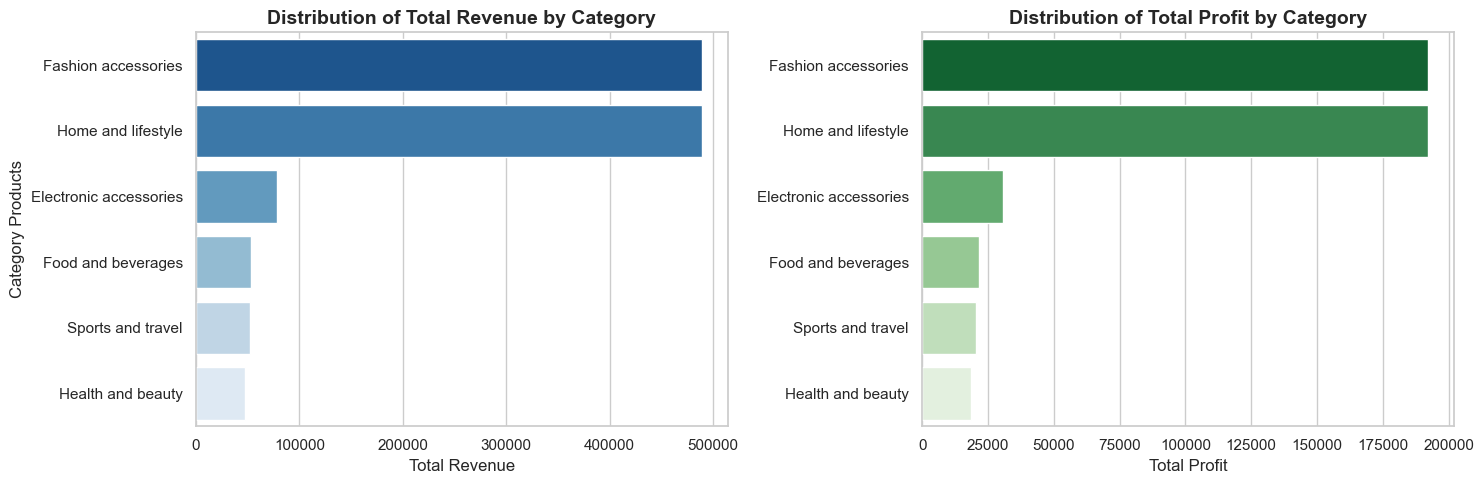

In [62]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

#Distribution of Total Revenue
sns.barplot(
    data=total_profit_results.sort_values('total_revenue', ascending=False),
    x='total_revenue',
    y='category',
    ax=axes[0],
    palette='Blues_r',
    hue='category',
    legend=False
)
axes[0].set_title('Distribution of Total Revenue by Category', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Total Revenue', fontsize=12)
axes[0].set_ylabel('Category Products', fontsize=12)

#Distribution of Total Profit
sns.barplot(
    data=total_profit_results.sort_values('total_profit', ascending=False),
    x='total_profit',
    y='category',
    ax=axes[1],
    palette='Greens_r',
    hue='category',
    legend=False
)
axes[1].set_title('Distribution of Total Profit by Category', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Total Profit', fontsize=12)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

**Key Findings**  
The revenue and profit visualization by category shows a sharp contrast. **Fashion accessories** and **Home and lifestyle** dominate sales volume and consistently provide the **highest profit margins** for the company. Conversely, **Health and beauty** and **Sports and travel** record the l**owest performance** and lag significantly behind.

**Operational Interpretation**  
This data disproves the assumption that all product departments contribute equally. Customers in these branches have a very strong tendency to spend on lifestyle and appearance products rather than health or sports items. The main drivers of cash flow in the store come from these two top categories.

**Actionable Recommendations**  
- Supply Chain Focus: Management must prioritize stock security for fashion and home goods. Stockouts in these two areas will severely hit total store revenue.

- Store Layout Evaluation: Consider reducing physical display areas or aisles for health and sports products. The remaining space can be allocated to expand the fashion and lifestyle sections to maximize the visibility of top-selling items.

**Workload Analysis: Branch Density Patterns**

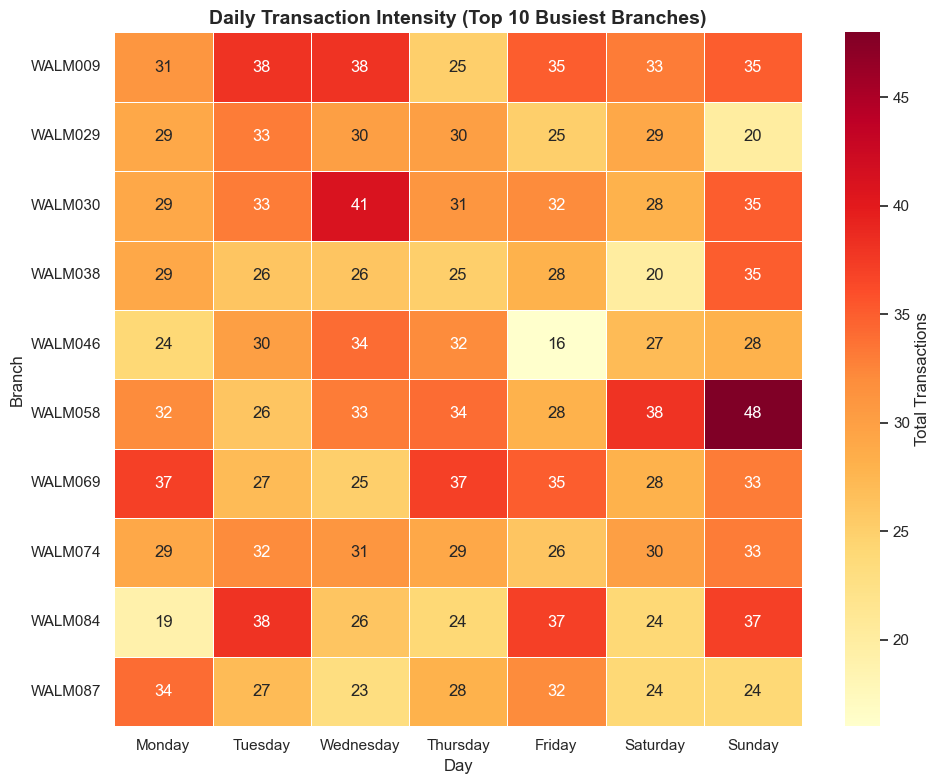

In [63]:
# 1. Query to get the full daily transaction intensity
heatmap_query = """
SELECT 
    "Branch",
    TRIM(TO_CHAR("date", 'Day')) AS name_of_day,
    COUNT(invoice_id) AS total_transactions
FROM walmart
GROUP BY "Branch", TRIM(TO_CHAR("date", 'Day'))
"""
heatmap_df = pd.read_sql(heatmap_query, engine)

# 2. Sort days chronologically
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_df['name_of_day'] = pd.Categorical(heatmap_df['name_of_day'], categories=day_order, ordered=True)

# 3. Calculate total transactions per branch and get the top 10
top_10_branches = heatmap_df.groupby('Branch')['total_transactions'].sum().nlargest(10).index

# 4. Filter the original dataframe to include only the top 10 branches
filtered_heatmap_df = heatmap_df[heatmap_df['Branch'].isin(top_10_branches)]

# 5. Create a pivot matrix from the filtered data
pivot_top_10 = filtered_heatmap_df.pivot_table(index='Branch', columns='name_of_day', values='total_transactions', fill_value=0, observed=False)

# 6. Render Heatmap
plt.figure(figsize=(10, 8)) 
sns.heatmap(pivot_top_10, cmap="YlOrRd", annot=True, fmt=".0f", linewidths=0.5, cbar_kws={'label': 'Total Transactions'})

plt.title('Daily Transaction Intensity (Top 10 Busiest Branches)', fontsize=14, fontweight='bold')
plt.xlabel('Day', fontsize=12)
plt.ylabel('Branch', fontsize=12)

plt.tight_layout()
plt.show()


**Key Findings**  
The heatmap of the 10 highest-volume branches shows that transaction activity is uneven throughout the week. Most major branches, like **WALM058 and WALM084**, **experience extreme transaction spikes on weekends**, specifically Saturdays and Sundays. However, there are anomalies like WALM030, which actually records its peak activity mid-week on Wednesday.

**Operational Interpretation**  
This pattern proves that a uniform scheduling policy for all days and branches can hurt the company financially. Stores bear full staff operational costs on weekdays when locations are generally quiet. Conversely, stores risk being understaffed during busy weekends, which causes long lines at the checkout and lowers service quality.

**Actionable Recommendations**  
- Dynamic Shift Scheduling: Store managers at branches with weekend spikes should consider using part-time staff specifically to cover Friday to Sunday shifts, while reducing the number of staff on duty from Monday to Thursday.
- Anomaly Investigation: Central management needs to investigate branches like WALM030. If the Wednesday crowd is driven by local promos or specific events, similar strategies could be tested at other branches to boost revenue on typically slow weekdays.

**Operating Hours Trend**

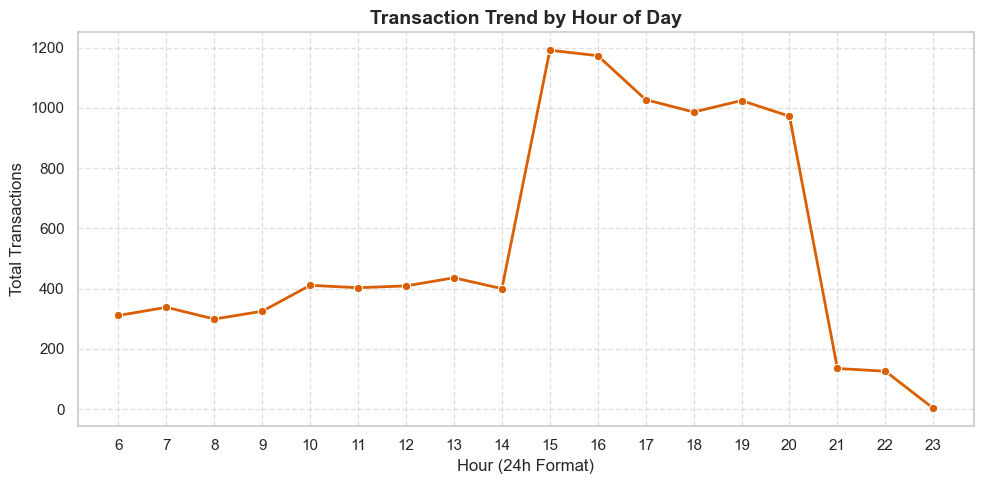

In [64]:
# 1. Query to get transaction counts by hour
hourly_query = """
SELECT 
    EXTRACT(HOUR FROM "time") AS transaction_hour,
    COUNT(invoice_id) AS total_transactions
FROM walmart
GROUP BY EXTRACT(HOUR FROM "time")
ORDER BY transaction_hour
"""
hourly_df = pd.read_sql(hourly_query, engine)

# 2. Render Line Chart
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=hourly_df, 
    x='transaction_hour', 
    y='total_transactions', 
    marker='o', 
    color='#d95f02',
    linewidth=2
)

plt.title('Transaction Trend by Hour of Day', fontsize=14, fontweight='bold')
plt.xlabel('Hour (24h Format)', fontsize=12)
plt.ylabel('Total Transactions', fontsize=12)

# Ensure all hour numbers appear on the X-axis
plt.xticks(hourly_df['transaction_hour']) 
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

**Key Findings**  
The line chart displays drastic fluctuations within a single day. **From 06:00 to 14:00**, **transaction volume remains stagnant at low numbers**, ranging between 300 and 400 transactions. **A massive spike occurs suddenly at 15:00**, immediately hitting around 1,200 transactions. This density remains **consistently high until 20:00**, and then the graph plummets near zero as the store prepares to close.

**Operational Interpretation**  
This data shows that customer shopping activity is concentrated within just a five-hour window. These numbers directly invalidate the assumption that store crowds peak at noon during lunch hours. Most customers visit the store in the late afternoon to evening, likely driven by post-work shopping habits. Operating all store facilities and keeping staff fully on standby since morning proves to be a budget waste that does not align with consumer behavior.

**Actionable Recommendations**  
- Optimal Shift Rotation: Reduce the number of cashiers and floor staff during the morning shift (06:00 to 14:00) to a functional minimum. Allocate maximum workload and manpower to prepare for the customer surge during the evening shift (15:00 to 20:00) to prevent long lines and maintain transaction speed.
- Restocking Schedule: Move all shelf restocking and store cleaning schedules to the morning when the store is still quiet. Placing logistics carts and warehouse staff in store aisles between 15:00 and 20:00 will only create space bottlenecks and ruin the comfort of a crowded store.

**Monthly Seasonality Analysis**

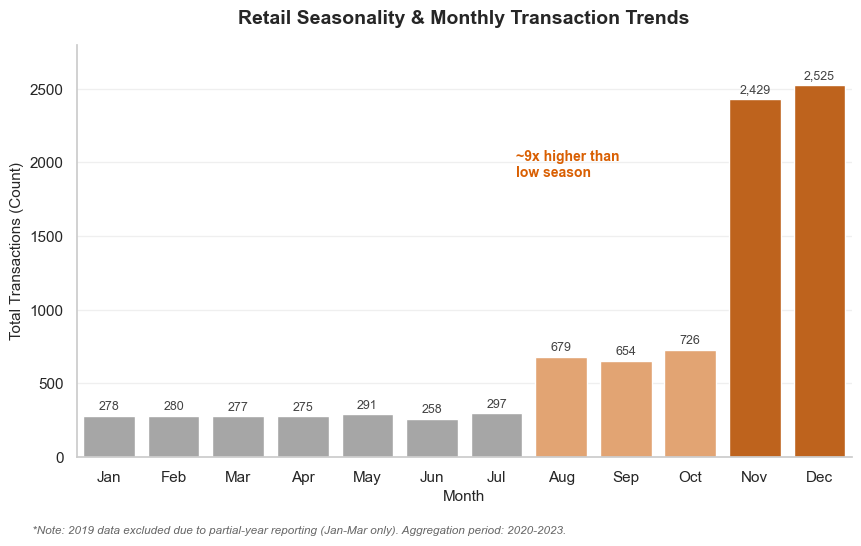

In [ ]:
# 1. Query monthly transaction volume, excluding 2019 (partial year, Jan-Mar only)
monthly_query = """
SELECT
    EXTRACT(MONTH FROM "date") AS month,
    COUNT(invoice_id) AS total_transactions,
    SUM("Total") AS total_revenue
FROM walmart_sales
WHERE EXTRACT(YEAR FROM "date") >= 2020
GROUP BY EXTRACT(MONTH FROM "date")
ORDER BY month;
"""
monthly_results = pd.read_sql(monthly_query, engine)

month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_results['month_label'] = monthly_results['month'].apply(lambda m: month_labels[int(m)-1])

# 2. Render bar chart
plt.figure(figsize=(10, 5.5))
colors = ['#d95f02' if m in [11,12] else ('#f4a261' if m in [8,9,10] else '#a6a6a6') 
          for m in monthly_results['month']]
ax = sns.barplot(data=monthly_results, x='month_label', y='total_transactions', 
                  palette=colors, hue='month_label', legend=False)
sns.despine()

plt.ylim(0, 2800)
for i, v in enumerate(monthly_results['total_transactions']):
    ax.text(i, v + 40, f'{v:,}', ha='center', fontsize=9, color='#444444')

plt.title('Retail Seasonality & Monthly Transaction Trends', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Month', fontsize=11)
plt.ylabel('Total Transactions (Count)', fontsize=11)
plt.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)

plt.annotate('~9x higher than\nlow season', xy=(10.5, 2450), xytext=(6.3, 1900),
             fontsize=10, color='#d95f02', fontweight='bold')

plt.figtext(0.08, 0.01, 
            "*Note: 2019 data excluded due to partial-year reporting (Jan-Mar only). "
            "Aggregation period: 2020-2023.", 
            fontsize=8.5, fontstyle='italic', color='#666666', wrap=True)

# Manual margin adjustment
plt.subplots_adjust(bottom=0.15, top=0.9)
plt.show()

**Key Findings**  
November and December show a dramatic transaction spike — roughly 9x higher than the low season (Jan-Jul). August-October show a moderate secondary rise, likely a pre-holiday buildup period. Note: 2019 data was excluded from this analysis since it only covers January-March, which would otherwise artificially inflate Q1 figures relative to other months.

**Operational Interpretation**  
This is the single strongest seasonal pattern in the entire dataset — far more pronounced than the intraday (hourly) pattern. It strongly suggests a holiday shopping season effect (Black Friday, Christmas), consistent across all observed years.

**Actionable Recommendations** 
- Inventory & Staffing Surge Planning: Begin scaling up stock levels and temporary staffing from October, with peak readiness by November 1st.
- Marketing Calendar Alignment: Concentrate promotional campaigns and ad spend in the Aug-Dec window rather than spreading budget evenly across the year.

##### **Supporting Operational Metrics**
Beyond the primary insights from the visualizations, the operational queries highlight other critical indicators that require immediate management attention:

- **Payment Method Landscape**: Cumulatively, credit cards dominate sales volume with over 4,200 transactions and 9,500 items sold, closely followed by E-wallets. However, at the branch level, E-wallets emerge as the top payment choice in the majority of locations (e.g., WALM001, WALM002, and WALM004). Cash transactions lag significantly behind. Stores must prioritize the maintenance of digital payment infrastructure and EDC machines, as customers have clearly shifted away from cash.

- **Customer Satisfaction Map (Ratings)**: Satisfaction scores are highly volatile and location-dependent. For instance, the 'Health and beauty' category achieved a near-perfect rating of 9.8 at branch WALM098, but the same category dropped to 6.9 at WALM100. On a city level, service quality is equally uneven; the city of Weslaco recorded a severe low rating of 3.0 for 'Fashion accessories'. Management cannot apply a blanket quality standard; each branch requires a tailored service audit.

- **YoY Revenue Decline (with Sample Size Caveat)**: Several branches show apparent revenue decline between 2022 and 2023. However, most of these branches have very few transactions per year (often under 20), making the percentage change statistically unreliable at the individual branch level. Branches meeting a minimum sample size threshold (≥20 transactions/year) should be prioritized for local investigation, while smaller branches require more data before conclusions can be drawn.

##### **Executive Summary and Strategic Next Steps**
The data reveals a clear disconnect between standard store operations and actual customer behavior. To maximize profitability and stop current losses, management must move away from a uniform operating approach and execute the following priorities:

1. Align Labor with Customer Traffic
The traditional morning focus is wasting resources. Stores must shift their heavy staffing and logistical work away from the quiet 06:00 to 14:00 window. Manpower must be concentrated on weekends and the critical 15:00 to 20:00 daily rush to handle the actual volume of shoppers.

2. Restructure Floor Space
Fashion and Home categories generate the highest total profit due to significantly higher transaction volume (10x+ more transactions than underperforming categories), not because of higher profit margins — margins are actually similar (~39-40%) across all categories. Store managers should physically expand display areas for these high-volume categories and reduce the footprint of underperforming departments to maximize revenue per square foot.

3. Investigate Flagged Branches (with Caveats)
A subset of branches show apparent revenue decline between 2022 and 2023. However, most of these branches have very low transaction volume (often under 20 per year), so the percentage figures should not be treated as confirmed operational crises. Central management should first prioritize branches that meet a minimum sample size threshold for investigation, and treat findings from low-volume branches as preliminary signals requiring more data before action is taken.